# 미분계수

$x=a$에서의 **미분계수**(순간변화율):

$$
f'(a) = \lim_{h \to 0} \frac{f(a+h) - f(a)}{h}
$$

이 극한이 존재하면 $f$는 $x=a$에서 **미분가능**

## 1. 정의로 직접 계산

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing()
x, h, a = sp.symbols('x h a')

f = x**3 + x**2 + x + 1
a0 = 1

quot = (f.subs(x, a0 + h) - f.subs(x, a0)) / h
print("차분몫:")
display(sp.simplify(quot))

f_prime_a = sp.limit(quot, h, 0)
print("h → 0 극한 = f'(1):")
display(f_prime_a)

차분몫:


h → 0 극한 = f'(1):


**차분몫**: <br>
=> 평균변화율 $\dfrac{f(a+h)-f(a)}{h}$

**sp.limit(..., h, 0)**: <br>
=> 정의 그대로 미분계수

## 2. sympy.diff로 도함수

In [2]:
f = x**3 + x**2 + x + 1
df = sp.diff(f, x)

print("f(x) =")
display(f)
print("f'(x) =")
display(df)

# 여러 점에서 미분계수
for pt in [0, 1, -1, 2]:
    print(f"f'({pt}) = {df.subs(x, pt)}")

f(x) =


f'(x) =


f'(0) = 1
f'(1) = 6
f'(-1) = 2
f'(2) = 17


**sp.diff(f, x)**: <br>
=> $x$에 대한 도함수

**df.subs(x, a)**: <br>
=> $f'(a)$

## 3. 수치로 확인 (작은 h)

In [3]:
f_num = sp.lambdify(x, f, 'numpy')
a0 = 1
exact = float(df.subs(x, a0))

print(f"정확한 f'(1) = {exact}")
for hh in [1e-1, 1e-2, 1e-3, 1e-4]:
    approx = (f_num(a0 + hh) - f_num(a0)) / hh
    print(f"h={hh:g}: 근사={approx:.8f}, 오차={abs(approx-exact):.2e}")

정확한 f'(1) = 6.0
h=0.1: 근사=6.41000000, 오차=4.10e-01
h=0.01: 근사=6.04010000, 오차=4.01e-02
h=0.001: 근사=6.00400100, 오차=4.00e-03
h=0.0001: 근사=6.00040001, 오차=4.00e-04


## 4. 그래프: 할선 → 접선

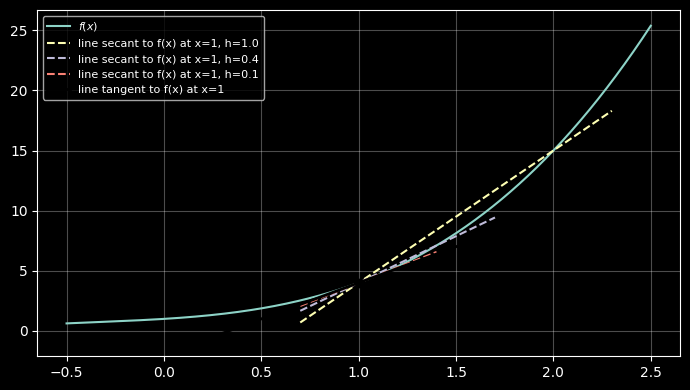

In [7]:
a0 = 1
xs = np.linspace(-0.5, 2.5, 400)
ys = f_num(xs)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(xs, ys, label=r"$f(x)$")

for hh, color in [(1.0, "C1"), (0.4, "C2"), (0.1, "C3")]:
    slope = (f_num(a0 + hh) - f_num(a0)) / hh
    # 할선: a와 a+h를 이은 직선
    xx = np.linspace(a0 - 0.3, a0 + hh + 0.3, 50)
    yy = f_num(a0) + slope * (xx - a0)
    ax.plot(xx, yy, ls="--", color=color, label=f"line secant to f(x) at x=1, h={hh}")

# 접선
slope_t = exact
xx = np.linspace(a0 - 0.8, a0 + 0.8, 50)
ax.plot(xx, f_num(a0) + slope_t * (xx - a0), color="k", lw=2, label="line tangent to f(x) at x=1")
ax.scatter([a0], [f_num(a0)], color="k", zorder=5)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()